In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("clean_data.csv")

In [3]:
df.sample(10)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
483808,547538,85099B,JUMBO BAG RED RETROSPOT,10,2011-03-23 15:17:00,1.95,13534.0,United Kingdom
269032,522982,22984,"CARD, GINGHAM ROSE",12,2010-09-19 14:03:00,0.42,12867.0,United Kingdom
743327,576236,22505,MEMO BOARD COTTAGE DESIGN,1,2011-11-14 13:31:00,4.95,13755.0,United Kingdom
27591,492571,22114,HOT WATER BOTTLE TEA AND SYMPATHY,12,2009-12-17 14:22:00,3.95,16439.0,United Kingdom
208510,515593,22060,LARGE CAKE STAND HANGING HEARTS,1,2010-07-13 13:29:00,9.95,16435.0,United Kingdom
39141,494613,21935,SUKI SHOULDER BAG,10,2010-01-15 13:31:00,1.65,14324.0,United Kingdom
706283,572771,23454,THREE MINI HANGING FRAMES,8,2011-10-26 10:24:00,4.15,16173.0,United Kingdom
83709,500326,35911A,MULTICOLOUR RABBIT EGG WARMER,6,2010-03-07 12:25:00,2.10,14877.0,United Kingdom
338295,530297,22411,JUMBO SHOPPER VINTAGE RED PAISLEY,1,2010-11-02 12:37:00,1.95,14966.0,United Kingdom
367036,533293,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-11-16 15:58:00,2.95,16145.0,United Kingdom


In [4]:
df.shape

(797884, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797884 entries, 0 to 797883
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      797884 non-null  object 
 1   StockCode    797884 non-null  object 
 2   Description  797884 non-null  object 
 3   Quantity     797884 non-null  int64  
 4   InvoiceDate  797884 non-null  object 
 5   Price        797884 non-null  float64
 6   Customer ID  797884 non-null  float64
 7   Country      797884 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 48.7+ MB


In [6]:
df['InvoiceDate']= pd.to_datetime(df['InvoiceDate'])

In [8]:
df['Year']= df['InvoiceDate'].dt.year
df['Month']= df['InvoiceDate'].dt.month
df['Day']= df['InvoiceDate'].dt.day
df['Time']= df['InvoiceDate'].dt.time

In [9]:
df["Country"].unique()

array(['United Kingdom', 'France', 'USA', 'Belgium', 'Australia', 'EIRE',
       'Germany', 'Portugal', 'Japan', 'Denmark', 'Netherlands', 'Poland',
       'Spain', 'Channel Islands', 'Italy', 'Cyprus', 'Greece', 'Norway',
       'Austria', 'Sweden', 'United Arab Emirates', 'Finland',
       'Switzerland', 'Unspecified', 'Nigeria', 'Malta', 'RSA',
       'Singapore', 'Bahrain', 'Thailand', 'Israel', 'Lithuania',
       'West Indies', 'Korea', 'Brazil', 'Canada', 'Iceland', 'Lebanon',
       'Saudi Arabia', 'Czech Republic', 'European Community'],
      dtype=object)

<Axes: xlabel='Year', ylabel='Quantity'>

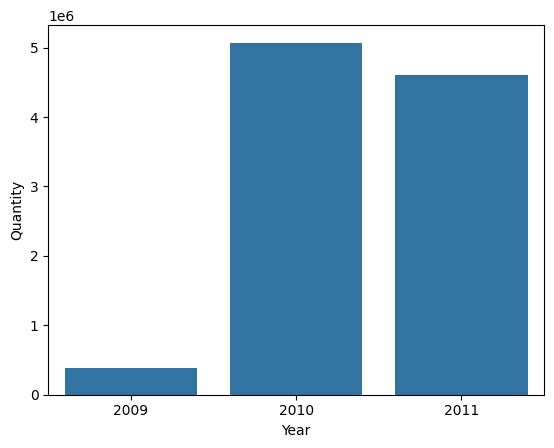

In [10]:
data = df.groupby('Year')['Quantity'].sum().reset_index()

sns.barplot(x='Year', y='Quantity', data=data)

<Axes: xlabel='Price', ylabel='Quantity'>

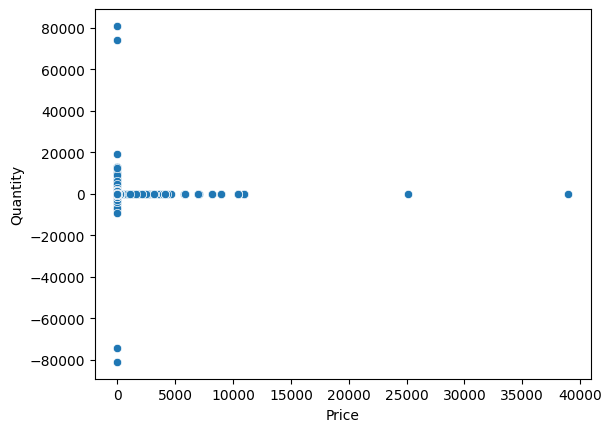

In [11]:
sns.scatterplot(x=df["Price"],y=df["Quantity"])

In [12]:
df = df[df['Price'] < 10000]

<Axes: xlabel='Price', ylabel='Quantity'>

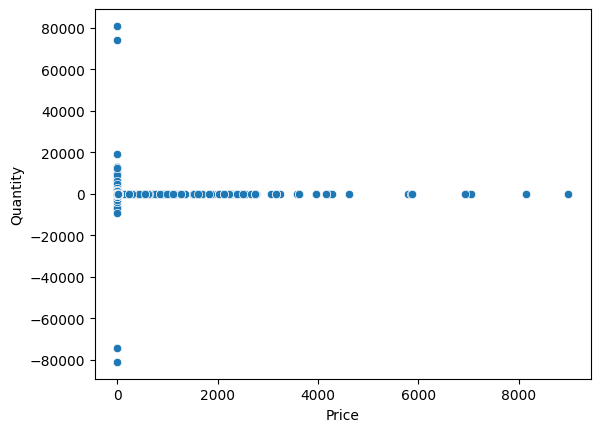

In [13]:
sns.scatterplot(x=df["Price"],y=df["Quantity"])

In [15]:
df[df["Price"]==0].value_counts().sum()

np.int64(70)

In [16]:
df[df["Price"] == 0]["Description"].value_counts().head(10)

Description
Manual                                 7
REGENCY CAKESTAND 3 TIER               2
This is a test product.                2
CHRISTMAS PUDDING TRINKET POT          2
36 FOIL STAR CAKE CASES                1
SET OF 2 CERAMIC CHRISTMAS REINDEER    1
SET OF 2 CERAMIC PAINTED HEARTS        1
SET OF 6 NATIVITY MAGNETS              1
JAM MAKING SET WITH JARS               1
 OVAL WALL MIRROR DIAMANTE             1
Name: count, dtype: int64

In [17]:
df[df["Price"] == 0]["Customer ID"].value_counts().sum()


np.int64(70)

In [14]:
# remove price value is 0

In [19]:
df[(df["Quantity"] > 0) & (df["Price"] > 0)].shape[0]

779422

In [20]:
sales_df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]
returns_df = df[df["Quantity"] < 0]

In [21]:
df['is_return'] = df['Quantity'] < 0

<Axes: xlabel='Year', ylabel='Quantity'>

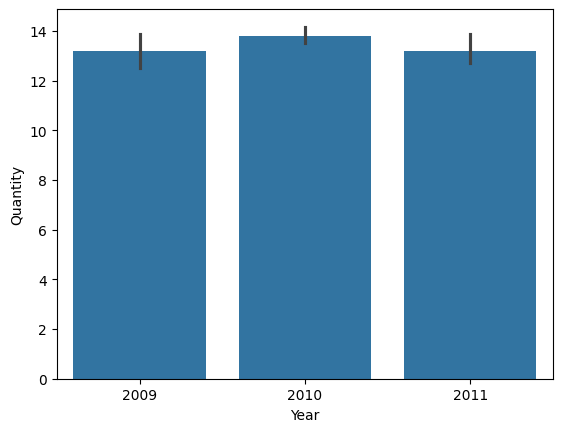

In [22]:
sns.barplot(x='Year', y='Quantity', data=sales_df)

In [23]:
returns_df['Quantity'] = returns_df['Quantity'].abs()

C:\Users\mahes\AppData\Local\Temp\ipykernel_22172\233708975.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  returns_df['Quantity'] = returns_df['Quantity'].abs()


<Axes: xlabel='Year', ylabel='Quantity'>

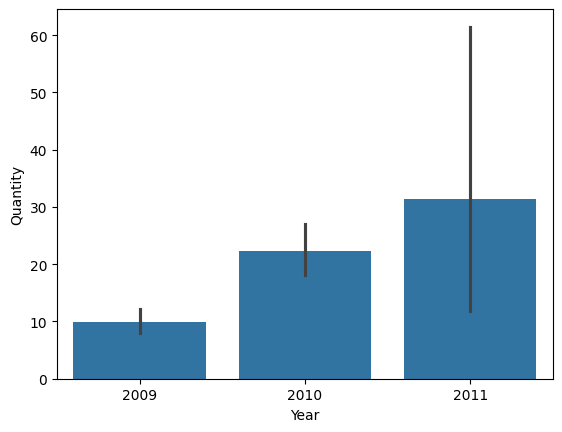

In [24]:
sns.barplot(x='Year', y='Quantity', data=returns_df)

In [25]:
df[df['is_return']==True]['Description'].value_counts().head(10)

Description
Manual                                391
REGENCY CAKESTAND 3 TIER              341
BAKING SET 9 PIECE RETROSPOT          208
STRAWBERRY CERAMIC TRINKET BOX        181
POSTAGE                               180
Discount                              165
WHITE HANGING HEART T-LIGHT HOLDER    133
WHITE CHERRY LIGHTS                   119
RED RETROSPOT CAKE STAND              106
JAM MAKING SET WITH JARS               86
Name: count, dtype: int64

<Axes: xlabel='Month', ylabel='Quantity'>

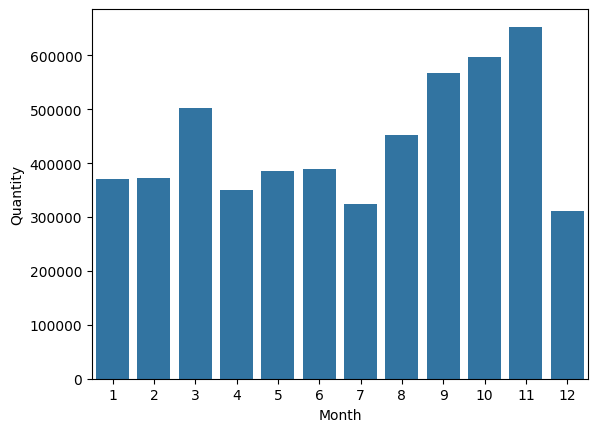

In [26]:
year_data = sales_df[sales_df['Year'] == 2010]
monthly_sales_2010 =year_data.groupby("Month")['Quantity'].sum().reset_index()
sns.barplot(x='Month',y='Quantity', data = monthly_sales_2010)

<Axes: xlabel='Month', ylabel='Quantity'>

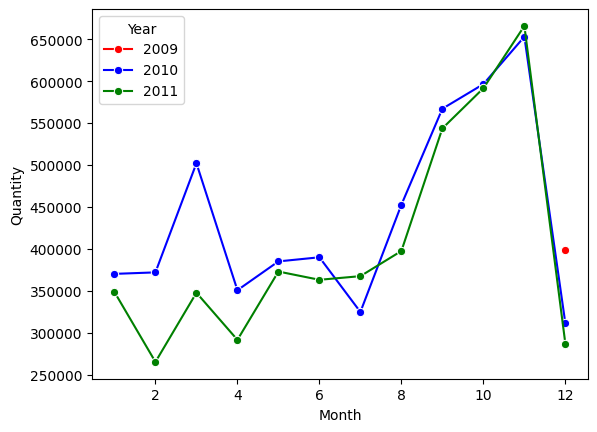

In [27]:
data = sales_df.groupby(['Year','Month'])['Quantity'].sum().reset_index()
sns.lineplot(x='Month', y='Quantity', hue='Year', data=data, marker='o',palette=['red', 'blue','green'])

<Axes: xlabel='Month', ylabel='Quantity'>

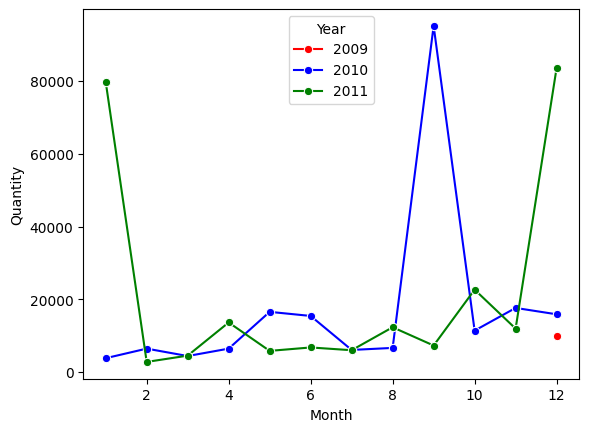

In [28]:
data = returns_df.groupby(['Year','Month'])['Quantity'].sum().abs().reset_index()
sns.lineplot(x='Month', y='Quantity', hue='Year', data=data, marker='o',palette=['red', 'blue','green'])

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Australia'),
  Text(1, 0, 'Denmark'),
  Text(2, 0, 'EIRE'),
  Text(3, 0, 'France'),
  Text(4, 0, 'Germany'),
  Text(5, 0, 'Netherlands'),
  Text(6, 0, 'Spain'),
  Text(7, 0, 'Sweden'),
  Text(8, 0, 'Switzerland'),
  Text(9, 0, 'United Kingdom')])

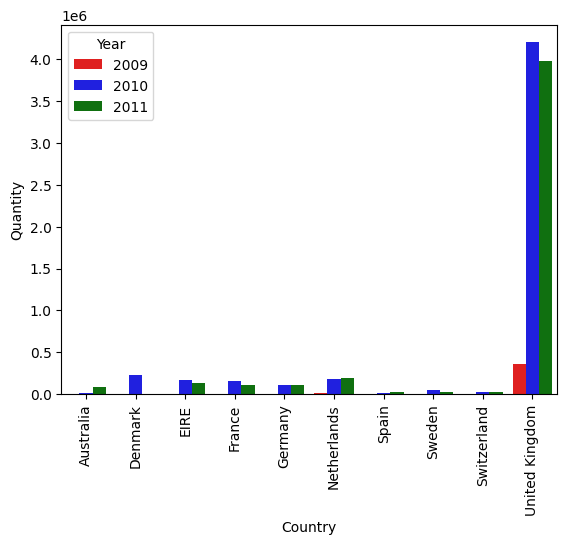

In [29]:
data = sales_df.groupby(['Country','Year'])['Quantity'].sum().reset_index()

top_countries = data.groupby('Country')['Quantity'].sum().reset_index()
top_countries = top_countries.sort_values(by='Quantity', ascending=False).head(10)

data = data[data['Country'].isin(top_countries['Country'])]

sns.barplot(x='Country', y='Quantity', hue='Year', data=data,palette=['red', 'blue','green'])
plt.xticks(rotation=90)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Channel Islands'),
  Text(1, 0, 'Denmark'),
  Text(2, 0, 'EIRE'),
  Text(3, 0, 'France'),
  Text(4, 0, 'Germany'),
  Text(5, 0, 'Japan'),
  Text(6, 0, 'Netherlands'),
  Text(7, 0, 'Spain'),
  Text(8, 0, 'USA'),
  Text(9, 0, 'United Kingdom')])

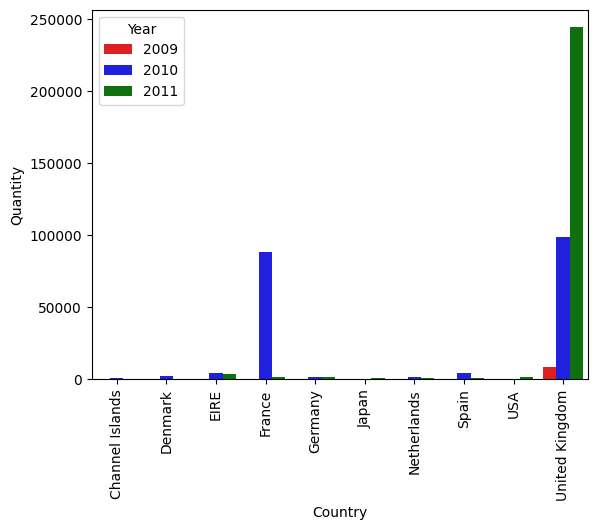

In [26]:
data = returns_df.groupby(['Country','Year'])['Quantity'].sum().abs().reset_index()

top_countries = data.groupby('Country')['Quantity'].sum().reset_index()
top_countries = top_countries.sort_values(by='Quantity', ascending=False).head(10)

data = data[data['Country'].isin(top_countries['Country'])]

sns.barplot(x='Country', y='Quantity', hue='Year', data=data,palette=['red', 'blue','green'])
plt.xticks(rotation=90)

<Axes: xlabel='Month'>

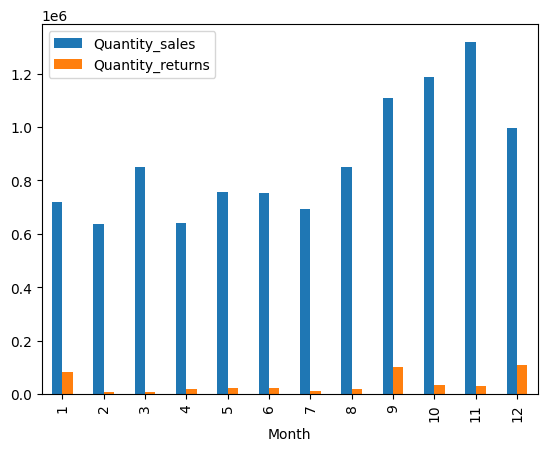

In [30]:
sales = sales_df.groupby('Month')['Quantity'].sum().reset_index()
returns = returns_df.groupby('Month')['Quantity'].sum().reset_index()


returns['Quantity'] = returns['Quantity'].abs()


data = sales.merge(returns, on='Month', how='outer', suffixes=('_sales', '_returns'))

data.set_index('Month')[['Quantity_sales','Quantity_returns']].plot(kind='bar')

In [31]:
sales = sales_df.groupby('Country')['Quantity'].sum().reset_index()
returns = returns_df.groupby('Country')['Quantity'].sum().reset_index()


returns['Quantity'] = returns['Quantity'].abs()

In [32]:
data = sales.merge(returns, on='Country', how='outer', suffixes=('_sales','_returns'))
data.fillna(0, inplace=True)

In [33]:
data.head(10)

,Country,Quantity_sales,Quantity_returns
0,Australia,103759,692.0
1,Austria,11578,272.0
2,Bahrain,755,0.0
3,Belgium,34768,180.0
4,Brazil,545,0.0
5,Canada,3657,0.0
6,Channel Islands,21396,1009.0
7,Cyprus,10950,298.0
8,Czech Republic,671,79.0
9,Denmark,237471,2707.0


In [34]:
top10_salse_country = sales.sort_values(by = 'Quantity',ascending=False).head(10)

In [35]:
top10_salse_country

,Country,Quantity
38,United Kingdom,8532409
24,Netherlands,383879
10,EIRE,318021
13,France,270287
9,Denmark,237471
14,Germany,225154
0,Australia,103759
33,Sweden,88495
34,Switzerland,52227
32,Spain,50307


In [36]:
top10_return_country = returns.sort_values(by = 'Quantity',ascending=False).head(10)

In [37]:
top10_return_country

,Country,Quantity
29,United Kingdom,351597
10,France,90330
7,EIRE,8554
24,Spain,5651
11,Germany,3357
6,Denmark,2707
18,Netherlands,2666
27,USA,1564
15,Japan,1505
3,Channel Islands,1009


In [38]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Year,Month,Day,Time,is_return
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009,12,1,07:45:00,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,07:45:00,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009,12,1,07:45:00,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009,12,1,07:45:00,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009,12,1,07:45:00,False


In [39]:
df['TotalPrice'] = df['Quantity'] * df['Price']

user_df = df.groupby("Customer ID").agg({
    'Invoice':'count',
    'Quantity':'sum',
    'Price':'mean',
    'TotalPrice': 'sum'
}).reset_index()

In [40]:
user_df.sample(10)

,Customer ID,Invoice,Quantity,Price,TotalPrice
3273,15620.0,136,1228,3.391691,1909.93
4973,17320.0,152,1182,4.233224,2444.85
2778,15125.0,261,8135,4.013831,16124.33
347,12693.0,83,524,5.122530,1640.42
5353,17701.0,24,109,5.754167,417.95
2922,15269.0,35,372,7.172286,1225.36
2860,15207.0,27,398,1.665185,653.77
2861,15208.0,49,354,4.702653,968.02
1985,14332.0,62,875,2.648871,1917.41
1573,13920.0,88,1768,2.722614,1734.88


In [42]:
import datetime as dt

snapshot_date = df['InvoiceDate'].max()

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Invoice': 'count',                                       # Frequency
    'TotalPrice': 'sum'                                       # Monetary
}).reset_index()

rfm.columns = ['CustomerID','Recency','Frequency','Monetary']

In [43]:
rfm.sample(10)  

,CustomerID,Recency,Frequency,Monetary
4177,16524.0,445,53,306.19
5821,18169.0,60,9,202.65
5675,18023.0,539,1,-3248.86
3985,16332.0,27,199,1979.57
5240,17588.0,99,75,2901.65
5637,17985.0,21,21,631.35
2834,15181.0,65,23,953.40
2857,15204.0,356,9,316.58
2758,15105.0,17,151,3094.91
355,12701.0,79,147,2446.41


In [44]:
top10 = rfm.sort_values(by='Monetary', ascending=False).head(10)

In [45]:
top10

,CustomerID,Recency,Frequency,Monetary
5754,18102.0,0,1050,570380.61
2299,14646.0,1,3890,523342.07
1809,14156.0,9,4118,296063.44
2564,14911.0,0,11444,265757.91
5102,17450.0,7,444,231390.55
1347,13694.0,3,1551,190020.84
5163,17511.0,2,2077,168491.62
69,12415.0,23,990,143269.29
4337,16684.0,3,749,141502.25
2714,15061.0,3,909,124961.98


In [46]:
low_value = rfm[
    (rfm['Recency'] > rfm['Recency'].quantile(0.75)) &
    (rfm['Frequency'] < rfm['Frequency'].quantile(0.25)) &
    (rfm['Monetary'] < rfm['Monetary'].quantile(0.25))
]

print(low_value.head(10))

     CustomerID  Recency  Frequency  Monetary
36      12382.0      681          1    -18.38
41      12387.0      414          9    143.94
46      12392.0      590          7    234.75
54      12400.0      413         11    205.25
58      12404.0      681          1     63.24
70      12416.0      656         11    202.56
120     12466.0      681          1     56.73
121     12467.0      385         18      0.00
141     12487.0      730          3    259.80
150     12496.0      619         10     45.34
